# siRNAEfficacyDB exploratory analysis

This notebook describes the observed structure of the processed siRNAEfficacyDB records. It does not train a model, evaluate causality, or establish sequence-design rules.

## tl;dr

- This source-separated descriptive analysis contains **3,544** processed siRNAEfficacyDB records across **42** source-reported target genes.
- Both strand fields are available for all records. The observed source-reported activity values span **-27.8 to 134.1** on the source `%Inhibition` scale.
- Sequence length, GC content, nucleotide composition, target frequency, and activity values are shown as observed distributions only. They do not support causal claims or activity prediction.

## Context & Methods

### Source and scope

Input: `data/processed/siRNAEfficacyDB_processed.csv`, generated from the source-preserved siRNAEfficacyDB download. This notebook uses this source alone and does not merge CMsiRNAdb or any other dataset.

### Key assumptions

- `activity_value`, `activity_unit`, and `activity_type` retain the source-reported endpoint and scale; no cross-assay normalization is performed.
- Basic sequence features are calculated from `antisense_sequence`. The feature utility uppercases sequence text for calculation only; source sequence strings remain unchanged in the processed dataset.
- Target names, assay text, and cell-line text are source-reported labels. No identifier resolution, ontology mapping, or biological interpretation is attempted.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.sequence_features import add_sequence_features

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'siRNAEfficacyDB_processed.csv'
FIGURE_DIRECTORY = PROJECT_ROOT / 'figures'
REPORT_PATH = PROJECT_ROOT / 'reports' / 'sirnaefficacydb_exploration_summary.md'
FIGURE_DIRECTORY.mkdir(exist_ok=True)
REPORT_PATH.parent.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
PLOT_COLOR = '#386FA4'
ACCENT_COLOR = '#C57B57'

## Data

### 1. Load the source-separated processed dataset

In [2]:
sirna_df = pd.read_csv(DATA_PATH, keep_default_na=False)
expected_source = {'siRNAEfficacyDB'}
assert set(sirna_df['source_dataset']) == expected_source, 'Unexpected source mixing detected.'
assert len(sirna_df.columns) == 23, 'Unexpected unified schema width.'
sirna_df.head(3)

,source_dataset,source_record_id,provenance_url,source_raw_record,source_raw_file,target_gene,sense_sequence,antisense_sequence,chemical_modification,chemical_modification_reported,...,activity_type,assay_method,assay_method_reported,cell_line,cell_type,concentration,concentration_unit,treatment_time,treatment_unit,reference
0,siRNAEfficacyDB,MC0001,https://figshare.com/articles/dataset/_b_Exper...,"{""ID"":""MC0001"",""Accession_number"":""NM_012249"",...",siRNA_data.xlsx,TC10,AAAUCAAUUAACAUAUUAG,CUAAUAUGUUAAUUGAUUUau,not_reported,not_reported,...,%Inhibition,Luciferase reporter assay,Luciferase reporter assay,HeLa,not_reported,50.0,nM,48.0,h,16025102
1,siRNAEfficacyDB,MC0002,https://figshare.com/articles/dataset/_b_Exper...,"{""ID"":""MC0002"",""Accession_number"":""NM_012249"",...",siRNA_data.xlsx,TC10,AUAAAUCAAUUAACAUAUU,AAUAUGUUAAUUGAUUUAUac,not_reported,not_reported,...,%Inhibition,Luciferase reporter assay,Luciferase reporter assay,HeLa,not_reported,50.0,nM,48.0,h,16025102
2,siRNAEfficacyDB,MC0003,https://figshare.com/articles/dataset/_b_Exper...,"{""ID"":""MC0003"",""Accession_number"":""NM_012249"",...",siRNA_data.xlsx,TC10,GAAAGGAAUUGUAUAAAUC,GAUUUAUACAAUUCCUUUCaa,not_reported,not_reported,...,%Inhibition,Luciferase reporter assay,Luciferase reporter assay,HeLa,not_reported,50.0,nM,48.0,h,16025102


## Results

### 2. Dataset overview

In [3]:
activity_values = pd.to_numeric(sirna_df['activity_value'], errors='coerce')
sequence_available = {
    'sense_sequence': int(sirna_df['sense_sequence'].ne('not_reported').sum()),
    'antisense_sequence': int(sirna_df['antisense_sequence'].ne('not_reported').sum()),
}
overview = pd.DataFrame({
    'metric': ['number of records', 'number of target genes', 'sense sequences available', 'antisense sequences available', 'activity values available'],
    'value': [
        len(sirna_df),
        sirna_df['target_gene'].nunique(),
        sequence_available['sense_sequence'],
        sequence_available['antisense_sequence'],
        int(activity_values.notna().sum()),
    ],
})
display(overview)
display(sirna_df['activity_type'].value_counts(dropna=False).rename('record_count').to_frame())

,metric,value
0,number of records,3544
1,number of target genes,42
2,sense sequences available,3544
3,antisense sequences available,3544
4,activity values available,3544


,record_count
%Inhibition,3544


### 3. Sequence analysis

Features below are descriptive calculations on the antisense strand.

In [4]:
feature_df = add_sequence_features(sirna_df, sequence_column='antisense_sequence')
sequence_summary = feature_df[[
    'sequence_length', 'GC_content', 'A_fraction', 'U_fraction', 'G_fraction', 'C_fraction'
]].describe().T
display(sequence_summary)

mean_composition = (
    feature_df[['A_fraction', 'U_fraction', 'G_fraction', 'C_fraction']]
    .mean()
    .rename(lambda label: label[0])
    .rename('mean_fraction')
    .to_frame()
)
display(mean_composition)

,count,mean,std,min,25%,50%,75%,max
sequence_length,3544.0,20.603837,0.797220,19.000000,21.000000,21.000000,21.000000,21.000000
GC_content,3544.0,0.524850,0.129026,0.142857,0.428571,0.523810,0.619048,0.952381
A_fraction,3544.0,0.208241,0.106095,0.000000,0.142857,0.190476,0.285714,0.666667
U_fraction,3544.0,0.266909,0.109596,0.000000,0.190476,0.263158,0.333333,0.666667
G_fraction,3544.0,0.267457,0.109639,0.000000,0.190476,0.263158,0.333333,0.631579
C_fraction,3544.0,0.257393,0.108241,0.000000,0.190476,0.238095,0.333333,0.631579


,mean_fraction
A,0.208241
U,0.266909
G,0.267457
C,0.257393


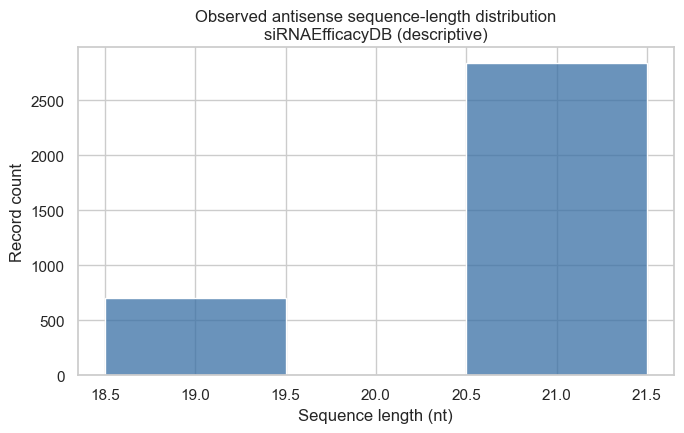

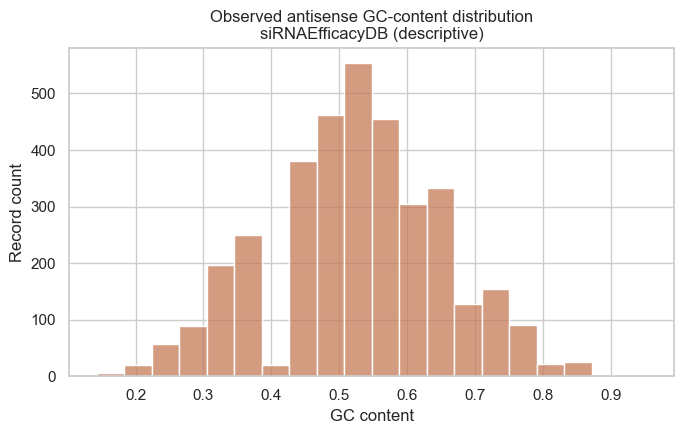

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.histplot(
    data=feature_df, x='sequence_length', discrete=True, color=PLOT_COLOR, ax=ax
)
ax.set(
    title='Observed antisense sequence-length distribution\nsiRNAEfficacyDB (descriptive)',
    xlabel='Sequence length (nt)', ylabel='Record count'
)

fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / 'siRNAEfficacyDB_sequence_length_distribution.png', dpi=250, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.histplot(data=feature_df, x='GC_content', bins=20, color=ACCENT_COLOR, ax=ax)
ax.set(
    title='Observed antisense GC-content distribution\nsiRNAEfficacyDB (descriptive)',
    xlabel='GC content', ylabel='Record count'
)

fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / 'siRNAEfficacyDB_gc_content_distribution.png', dpi=250, bbox_inches='tight')
plt.show()

### 4. Target analysis

Target labels are retained exactly as reported by the source.

In [6]:
top_targets = sirna_df['target_gene'].value_counts().head(15)
top_target_table = top_targets.rename_axis('target_gene').rename('record_count').to_frame()
top_target_table['record_share'] = top_target_table['record_count'] / len(sirna_df)
display(top_target_table.style.format({'record_share': '{:.1%}'}))

,record_count,record_share
target_gene,,
EGFP,702,19.8%
Mmp7,150,4.2%
C6orf110,145,4.1%
TCAP,144,4.1%
RAB6IP1,126,3.6%
Cyclophilin B,90,2.5%
P2RX3,90,2.5%
Firefly luciferase,87,2.5%
UBE2G1,79,2.2%


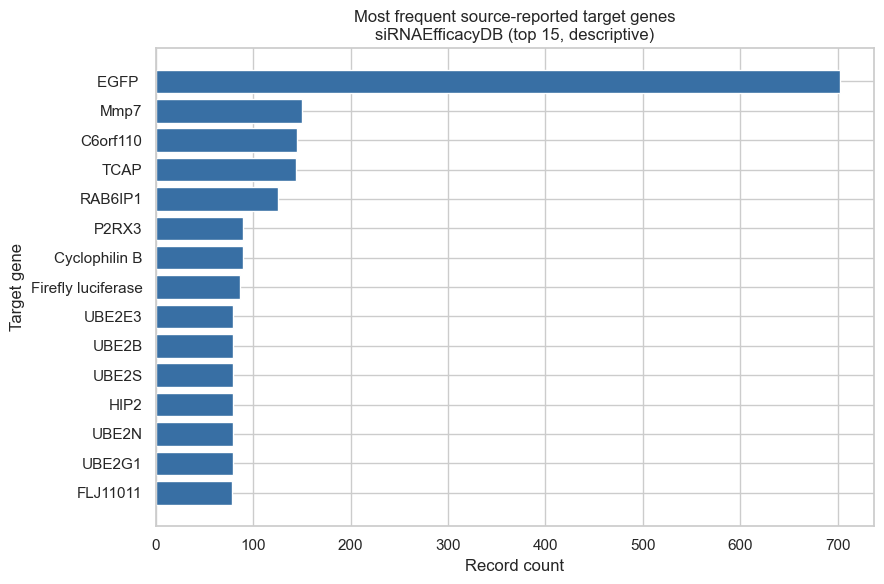

In [7]:
plot_targets = top_targets.sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_targets.index, plot_targets.values, color=PLOT_COLOR)
ax.set(
    title='Most frequent source-reported target genes\nsiRNAEfficacyDB (top 15, descriptive)',
    xlabel='Record count', ylabel='Target gene'
)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / 'siRNAEfficacyDB_top_target_genes.png', dpi=250, bbox_inches='tight')
plt.show()

### 5. Activity analysis

The histogram displays the source-reported `%Inhibition` values without rescaling.

In [8]:
activity_summary = activity_values.describe().to_frame(name='activity_value')
activity_range = pd.DataFrame({
    'minimum': [activity_values.min()],
    'maximum': [activity_values.max()],
    'range_width': [activity_values.max() - activity_values.min()],
}, index=['source-reported %Inhibition'])
display(activity_summary)
display(activity_range)

,activity_value
count,3544.000000
mean,65.100121
std,22.802328
min,-27.800000
25%,50.152500
50%,67.000000
75%,82.525000
max,134.100000


,minimum,maximum,range_width
source-reported %Inhibition,-27.8,134.1,161.9


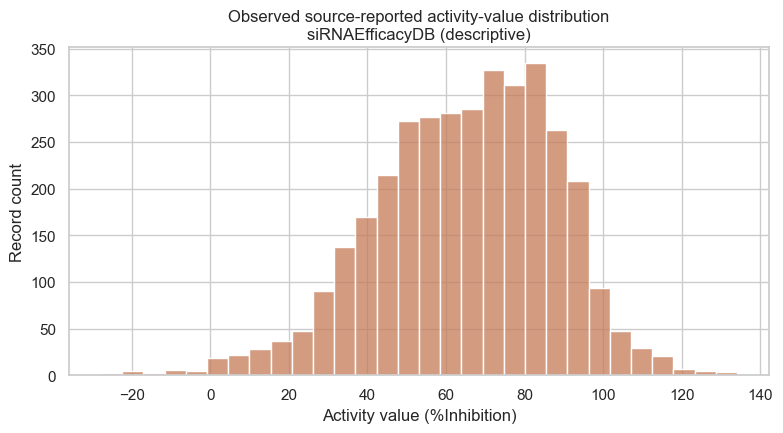

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(activity_values.dropna(), bins=30, color=ACCENT_COLOR, ax=ax)
ax.set(
    title='Observed source-reported activity-value distribution\nsiRNAEfficacyDB (descriptive)',
    xlabel='Activity value (%Inhibition)', ylabel='Record count'
)
fig.tight_layout()
fig.savefig(FIGURE_DIRECTORY / 'siRNAEfficacyDB_activity_value_distribution.png', dpi=250, bbox_inches='tight')
plt.show()

## Takeaways

- The notebook presents observed distributions for records from one public source.
- It does not claim that any sequence feature causes a particular activity value.
- Reported target frequencies reflect this source dataset and should not be interpreted as therapeutic prevalence or target importance.
- Activity values retain the source endpoint and should not be treated as a cross-dataset benchmark without a separate comparability review.

### 6. Write the descriptive summary report

In [10]:
def markdown_table(frame, float_format=None):
    if float_format is None:
        return frame.to_markdown()
    return frame.to_markdown(floatfmt=float_format)

report_lines = [
    '# siRNAEfficacyDB exploratory analysis summary',
    '',
    '## Scope',
    '',
    'This is a source-separated descriptive analysis of `siRNAEfficacyDB_processed.csv`. It contains no predictive model, causal inference, cross-source pooling, or biological efficacy claim.',
    '',
    '## Dataset overview',
    '',
    markdown_table(overview, float_format='.3f'),
    '',
    '### Activity type distribution',
    '',
    markdown_table(sirna_df['activity_type'].value_counts(dropna=False).rename('record_count').to_frame()),
    '',
    '## Observed sequence distributions',
    '',
    'Features were calculated descriptively from the antisense strand.',
    '',
    '### Sequence length and GC content',
    '',
    markdown_table(sequence_summary.loc[['sequence_length', 'GC_content']].round(3), float_format='.3f'),
    '',
    '### Mean nucleotide composition',
    '',
    markdown_table(mean_composition.round(3), float_format='.3f'),
    '',
    '## Observed target distribution',
    '',
    'Top source-reported target labels are shown without gene-name normalization.',
    '',
    markdown_table(top_target_table.head(10).round({'record_share': 3}), float_format='.3f'),
    '',
    '## Observed activity distribution',
    '',
    markdown_table(activity_summary.round(3), float_format='.3f'),
    '',
    markdown_table(activity_range.round(3), float_format='.3f'),
    '',
    '## Interpretation boundary',
    '',
    'All values and figures are observed distributions in this source. They do not show that a sequence feature causes activity, do not establish a biological mechanism, and do not constitute an activity benchmark across databases.',
]
REPORT_PATH.write_text('\n'.join(report_lines) + '\n', encoding='utf-8')
print(f'Wrote descriptive summary: {REPORT_PATH}')

Wrote descriptive summary: reports/sirnaefficacydb_exploration_summary.md
